In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("AmesHousing.csv")

In [ ]:
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [ ]:
df.isna().sum().head(50)

,0
Order,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,490
Lot Area,0
Street,0
Alley,2732
Lot Shape,0
Land Contour,0


In [ ]:
drop_col = [ "Misc Feature" , "Fence" , "Pool QC" , "Fireplace Qu" , "Mas Vnr Type" , "Alley"]

# plt.figure(figsize=(15,10))
# for i in drop_col:
#   sns.boxplot(x=i , y='SalePrice' , data=df)



In [ ]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [ ]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [ ]:
# To get Numerical features (int64, float64)
numeric_features = df.select_dtypes(include=['number']).columns.tolist()

# To get Categorical features (object, category)
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Quick summary of counts
print(f"Numerical Features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")

Numerical Features (39): ['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']
Categorical Features (43): ['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Typ

In [ ]:
df = df.drop(drop_col , axis=1)

In [ ]:
Numerical_col = ['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']
Categorical_col = ['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']



<Axes: xlabel='SalePrice', ylabel='Count'>

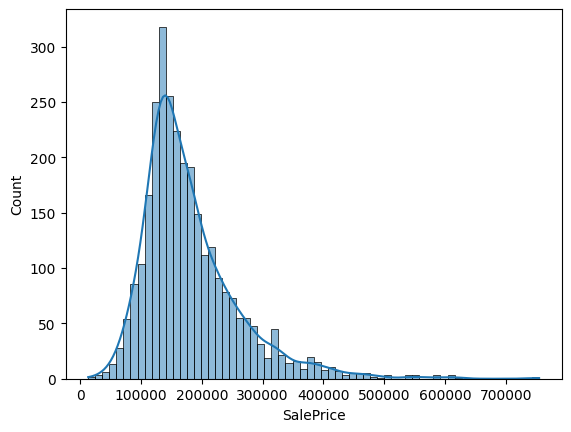

In [ ]:
sns.histplot(df['SalePrice'] , kde=True)

In [ ]:
# import numpy as np
# df['SalePrice_Log'] = np.log1p(df['SalePrice'])

In [ ]:
# df['SalePrice_sqrt'] = np.sqrt(df['SalePrice'])

<Axes: xlabel='SalePrice', ylabel='Count'>

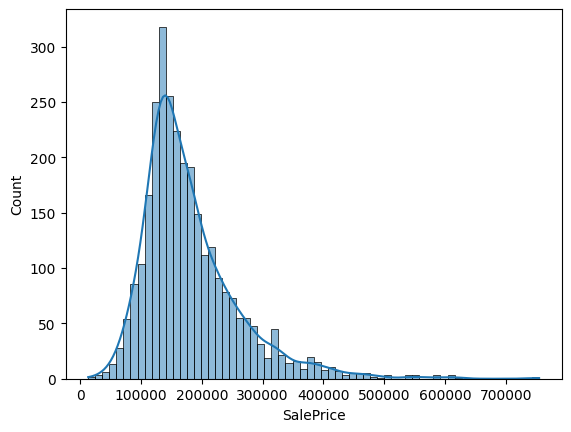

In [ ]:
sns.histplot(df['SalePrice'] , kde=True)

In [ ]:
import numpy as np

# # Convert back to original scale
# df['SalePrice_Original'] = np.expm1(df['SalePrice'])

# # Verification
# print(df[['SalePrice', 'SalePrice_Original']].head())

# df['SalePrice'] = df['SalePrice_Original']

In [ ]:
numeric_features

['Order',
 'PID',
 'MS SubClass',
 'Lot Frontage',
 'Lot Area',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 'Mas Vnr Area',
 'BsmtFin SF 1',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Gr Liv Area',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Full Bath',
 'Half Bath',
 'Bedroom AbvGr',
 'Kitchen AbvGr',
 'TotRms AbvGrd',
 'Fireplaces',
 'Garage Yr Blt',
 'Garage Cars',
 'Garage Area',
 'Wood Deck SF',
 'Open Porch SF',
 'Enclosed Porch',
 '3Ssn Porch',
 'Screen Porch',
 'Pool Area',
 'Misc Val',
 'Mo Sold',
 'Yr Sold',
 'SalePrice']

In [ ]:
cl = ['Order',
 'PID',
 'MS SubClass',
 'Lot Frontage',
 'Lot Area',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 'Mas Vnr Area',
 'BsmtFin SF 1',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Gr Liv Area',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Full Bath',
 'Half Bath',"SalePrice"]

In [ ]:
df[cl].corr()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,SalePrice
Order,1.000000,0.173593,0.011797,-0.007034,0.031354,-0.048500,-0.011054,-0.052319,-0.075566,-0.030907,...,-0.028719,-0.013201,-0.000417,0.013589,-0.009342,-0.042539,0.024978,-0.044985,-0.039749,-0.031408
PID,0.173593,1.000000,-0.001281,-0.096918,0.034868,-0.263147,0.104451,-0.343388,-0.157111,-0.229283,...,-0.189642,-0.141902,-0.003289,0.056940,-0.107579,-0.037759,0.004328,-0.171431,-0.166636,-0.246521
MS SubClass,0.011797,-0.001281,1.000000,-0.420135,-0.204613,0.039419,-0.067349,0.036579,0.043397,0.002730,...,-0.219445,-0.247828,0.304237,0.025765,0.068061,0.013701,-0.003329,0.134631,0.175879,-0.085092
Lot Frontage,-0.007034,-0.096918,-0.420135,1.000000,0.491313,0.212042,-0.074448,0.121562,0.091712,0.222407,...,0.353773,0.457391,0.029187,0.005249,0.383822,0.108915,-0.024724,0.184521,0.041880,0.357318
Lot Area,0.031354,0.034868,-0.204613,0.491313,1.000000,0.097188,-0.034759,0.023258,0.021682,0.126830,...,0.253589,0.332235,0.032996,0.000812,0.285599,0.125877,0.026903,0.127433,0.035497,0.266549
Overall Qual,-0.048500,-0.263147,0.039419,0.212042,0.097188,1.000000,-0.094812,0.597027,0.569609,0.429418,...,0.547294,0.477837,0.241402,-0.048680,0.570556,0.167858,-0.041647,0.522263,0.268853,0.799262
Overall Cond,-0.011054,0.104451,-0.067349,-0.074448,-0.034759,-0.094812,1.000000,-0.368773,0.047680,-0.135340,...,-0.173344,-0.157052,0.006218,0.009175,-0.115643,-0.042766,0.084455,-0.214316,-0.088127,-0.101697
Year Built,-0.052319,-0.343388,0.036579,0.121562,0.023258,0.597027,-0.368773,1.000000,0.612095,0.313292,...,0.407526,0.310463,0.016828,-0.144282,0.241726,0.211849,-0.030626,0.469406,0.269268,0.558426
Year Remod/Add,-0.075566,-0.157111,0.043397,0.091712,0.021682,0.569609,0.047680,0.612095,1.000000,0.196928,...,0.297481,0.242108,0.158939,-0.060365,0.316855,0.134387,-0.046292,0.457266,0.211771,0.532974
Mas Vnr Area,-0.030907,-0.229283,0.002730,0.222407,0.126830,0.429418,-0.135340,0.313292,0.196928,1.000000,...,0.397040,0.395736,0.121805,-0.057701,0.403611,0.140113,0.015421,0.260153,0.192965,0.508285


In [ ]:
# plt.figure(figsize=(12,8))
# sns.heatmap(df.corr(numeric_only=True),annot=True)
# plt.show()

In [ ]:
Categorical_col

['MS Zoning',
 'Street',
 'Alley',
 'Lot Shape',
 'Land Contour',
 'Utilities',
 'Lot Config',
 'Land Slope',
 'Neighborhood',
 'Condition 1',
 'Condition 2',
 'Bldg Type',
 'House Style',
 'Roof Style',
 'Roof Matl',
 'Exterior 1st',
 'Exterior 2nd',
 'Mas Vnr Type',
 'Exter Qual',
 'Exter Cond',
 'Foundation',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin Type 2',
 'Heating',
 'Heating QC',
 'Central Air',
 'Electrical',
 'Kitchen Qual',
 'Functional',
 'Fireplace Qu',
 'Garage Type',
 'Garage Finish',
 'Garage Qual',
 'Garage Cond',
 'Paved Drive',
 'Pool QC',
 'Fence',
 'Misc Feature',
 'Sale Type',
 'Sale Condition']

In [ ]:
cl = ['MS Zoning',
 'Street',
 'Lot Shape',
 'Land Contour',
 'Utilities',
 'Lot Config',
 'Land Slope',
 'Neighborhood',
 ]


cl_2 = ['Condition 2',
 'Bldg Type',
 'House Style',
 'Roof Style',
 'Roof Matl',
 'Exterior 1st',
 'Exterior 2nd',
        'Exter Qual',
 ]



cl_3 = [
     'Exter Cond',
 'Foundation',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin Type 2',
 'Heating',


 ]


cl_4 = [ 'Central Air',
 'Electrical',
 'Kitchen Qual','Heating QC','Condition 1',
         'Electrical',
 'Kitchen Qual',
 'Functional',

 ]


cl_5 = ['Fireplace Qu','Garage Type',
 'Garage Finish',
 'Garage Qual',
 'Garage Cond',
 'Paved Drive',
 'Pool QC',
 'Fence',
]

cl_5 = [
 'Sale Type',
 'Sale Condition']

In [ ]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond',
       'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Garage Type',
       'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area',


In [ ]:
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,IR1,Low,AllPub,...,0,0,0,0,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,Reg,Lvl,AllPub,...,0,0,0,0,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2006,WD,Normal,170000


In [ ]:
# df['SalePrice'] =

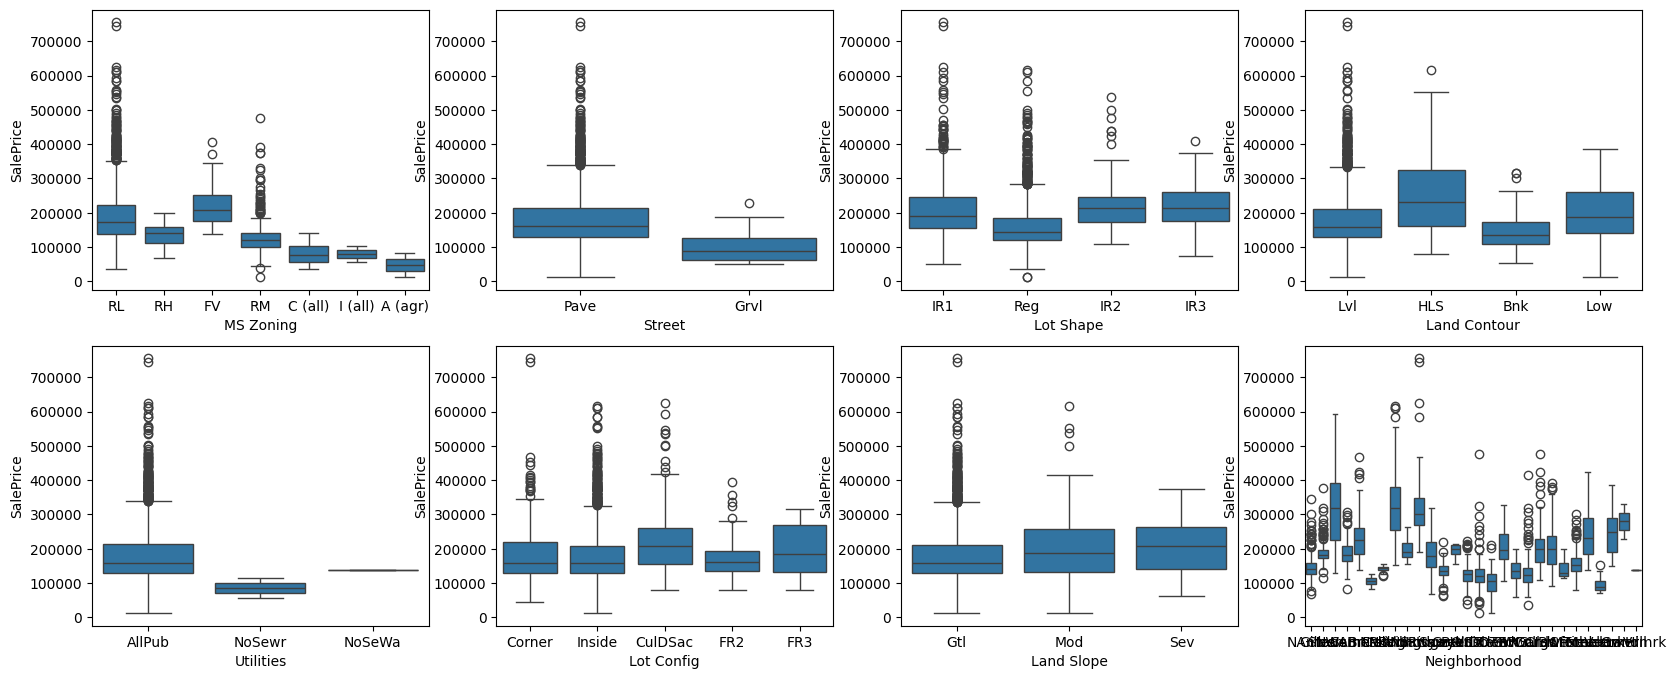

In [ ]:
def Boxplot(cl , j):
  plt.subplot(2 , 4 , j)
  sns.boxplot(x=cl , y='SalePrice' , data=df)

plt.figure(figsize=(20,8))
for i in range( len(cl)):
  Boxplot(cl[i] , i+1)

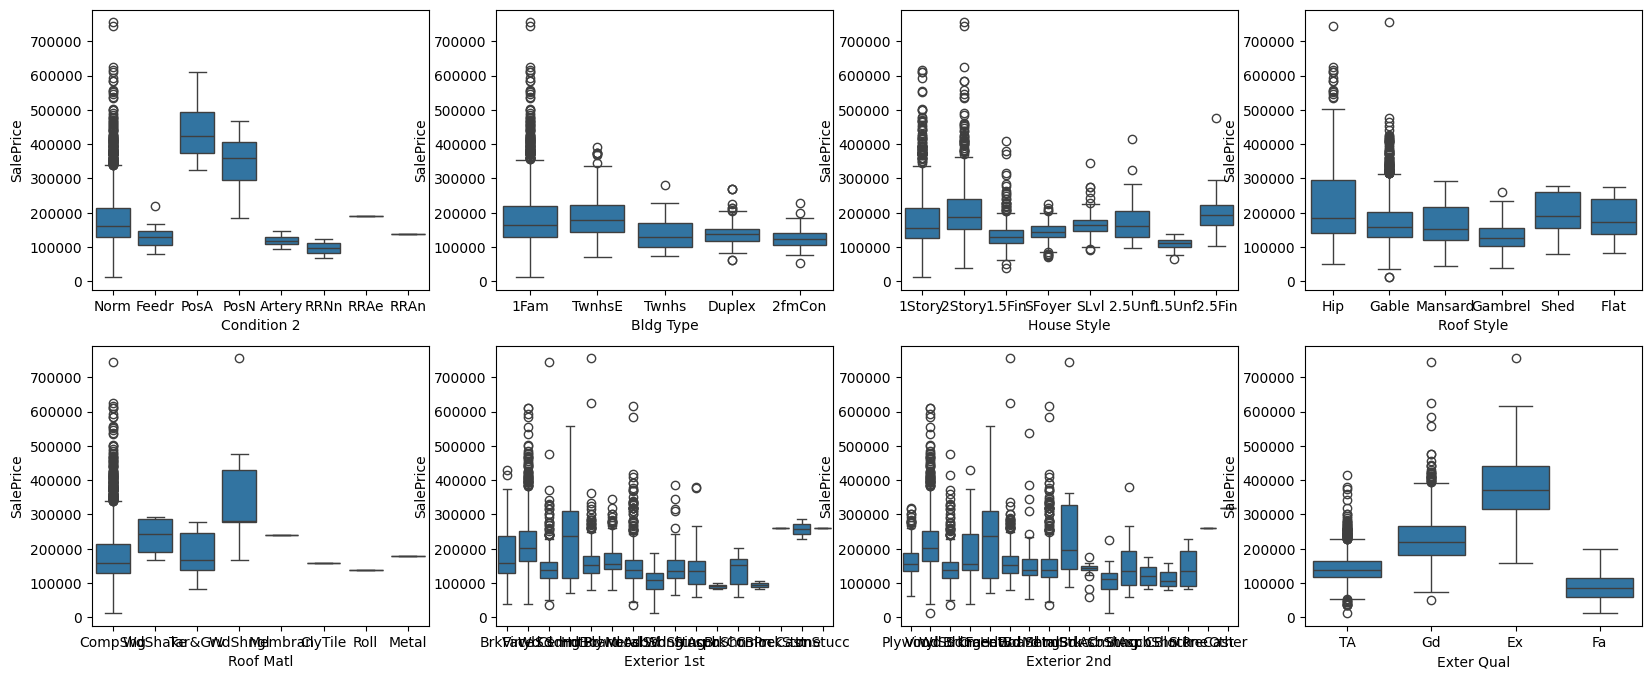

In [ ]:
plt.figure(figsize=(20,8))
for i in range( len(cl_2)):
  Boxplot(cl_2[i] , i+1)

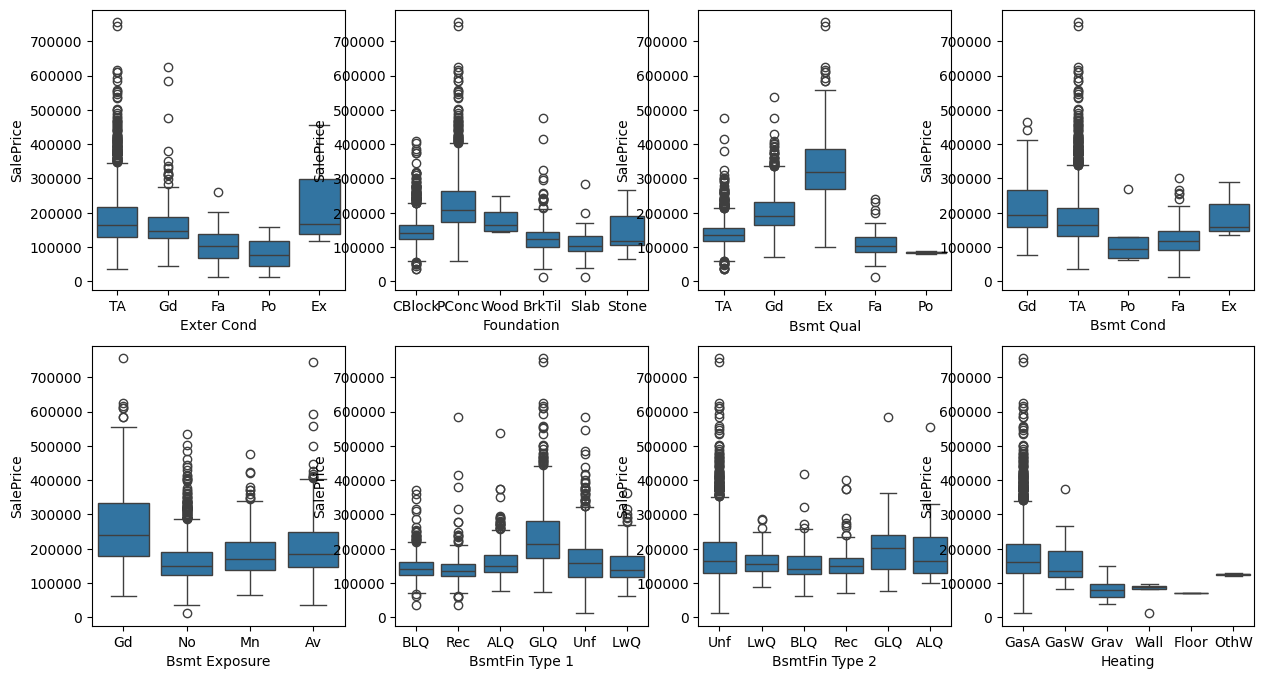

In [ ]:
plt.figure(figsize=(15,8))
for i in range(len(cl_3)):
  Boxplot(cl_3[i] , i+1)

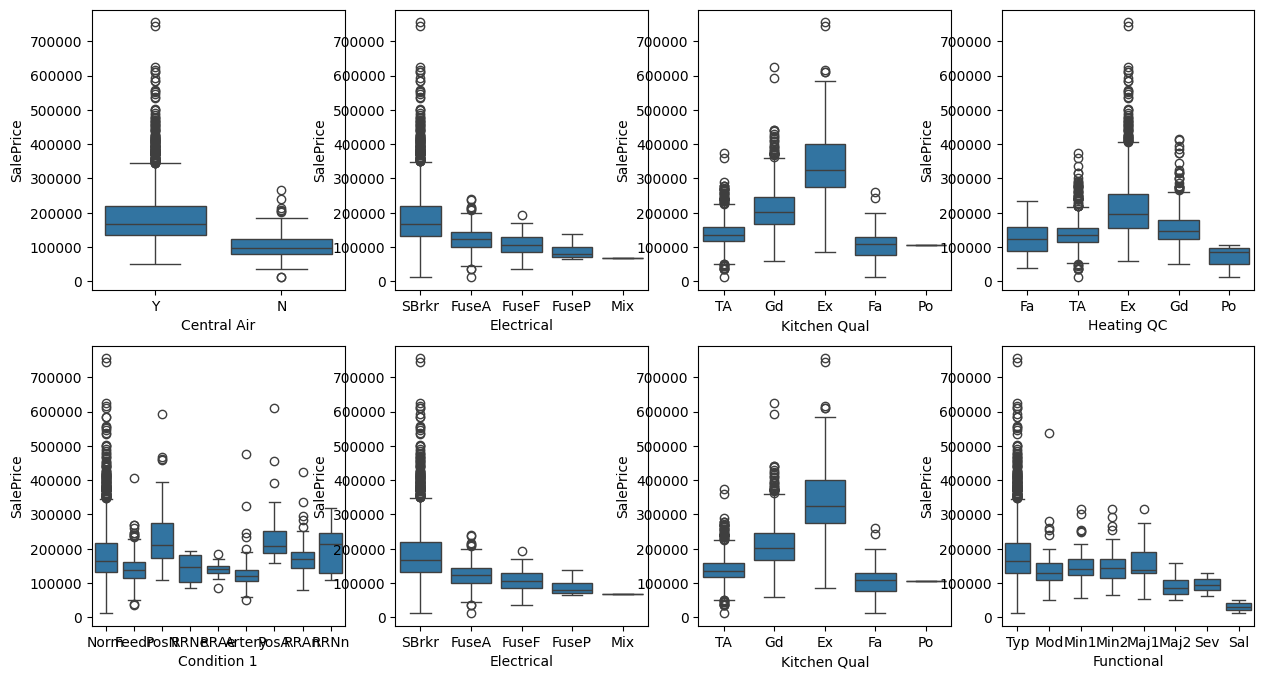

In [ ]:
plt.figure(figsize=(15,8))
for i in range(len(cl_4)):
  Boxplot(cl_4[i] , i+1)

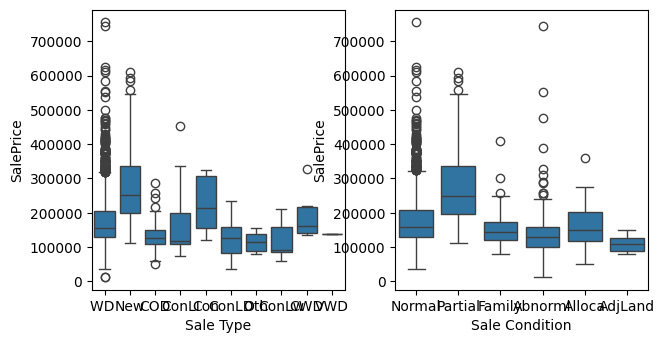

In [ ]:
plt.figure(figsize=(15,8))
for i in range(len(cl_5)):
  Boxplot(cl_5[i] , i+1)

<Axes: xlabel='Overall Qual', ylabel='SalePrice'>

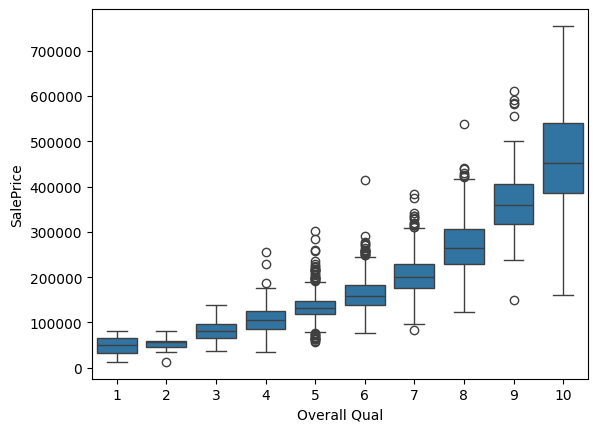

In [ ]:
sns.boxplot(x=df['Overall Qual'] , y=df['SalePrice'])

In [ ]:
df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
Overall Qual,0.799262
Gr Liv Area,0.706780
Garage Cars,0.647877
Garage Area,0.640401
Total Bsmt SF,0.632280
1st Flr SF,0.621676
Year Built,0.558426
Full Bath,0.545604
Year Remod/Add,0.532974


In [ ]:
col_60 = [ "Overall Qual",
"Gr Liv Area",
"Garage Cars",
"Garage Area",
"Total Bsmt SF",
"1st Flr SF",
           '2nd Flr SF',]

col_40 = ["Year Built",
"Full Bath",
"Year Remod/Add" , "Garage Yr Blt",
"Mas Vnr Area",
"TotRms AbvGrd",
"Fireplaces",
"BsmtFin SF"]

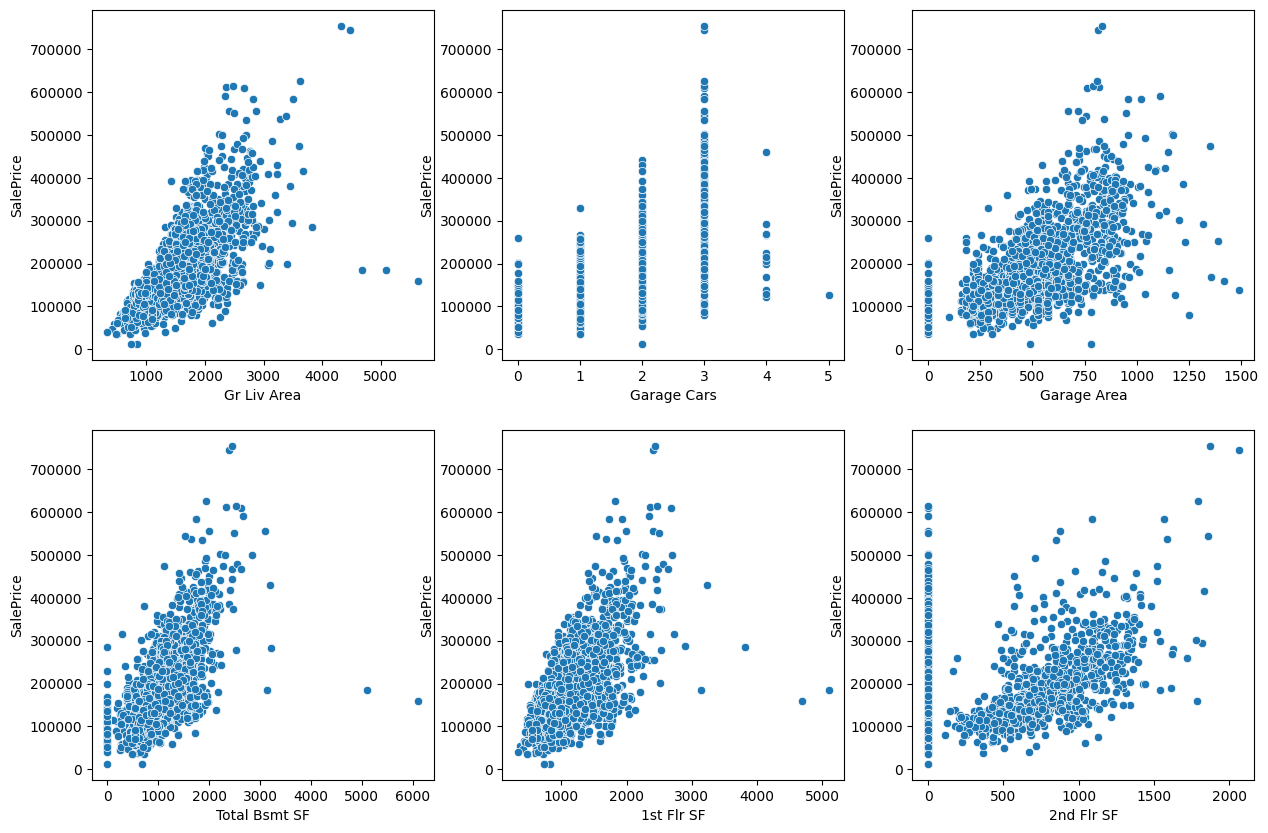

In [ ]:
def Scatter(cl , j):
  plt.subplot(2,3,j)
  sns.scatterplot(x=cl , y='SalePrice' , data=df)

plt.figure(figsize=(15,10))
for i in range(1 , len(col_60)):
  Scatter(col_60[i] , i)

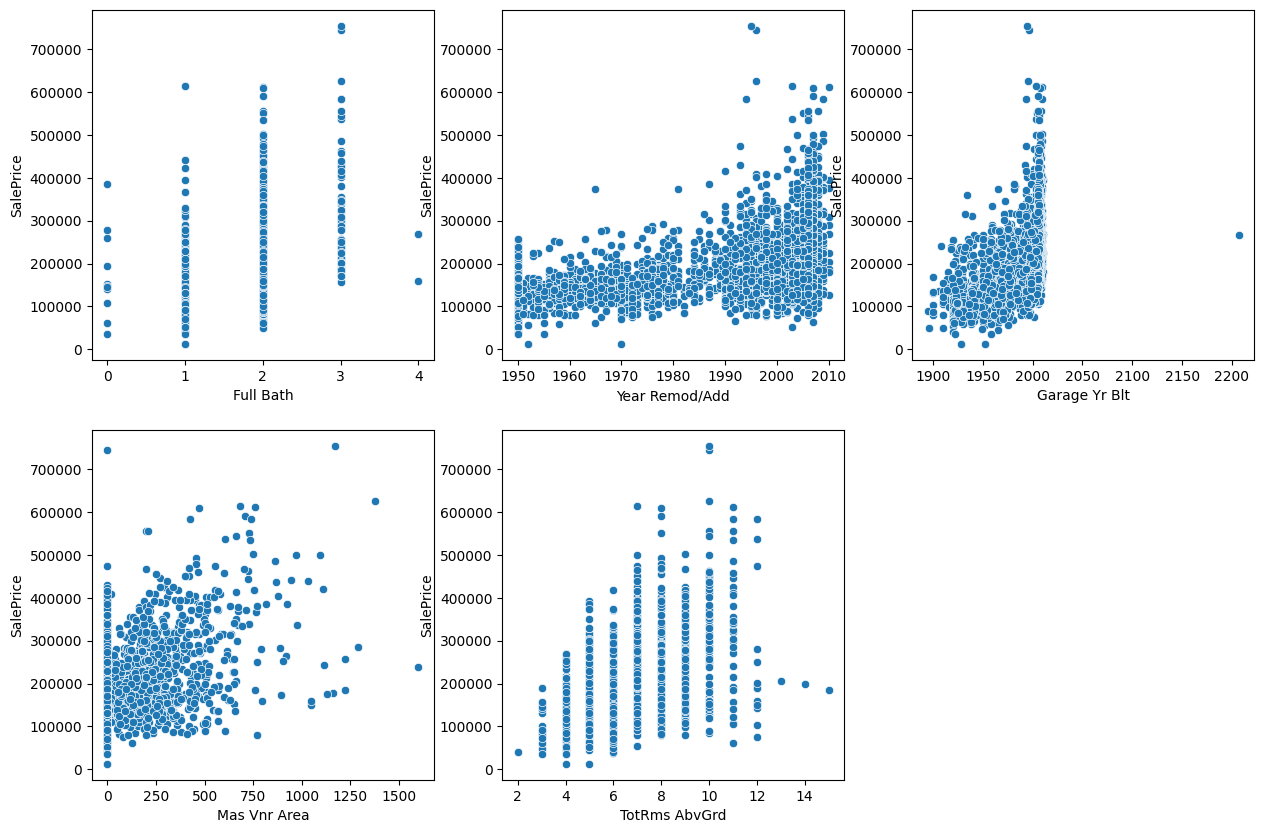

In [ ]:
plt.figure(figsize=(15,10))
for i in range(1 , len(col_40)-2):
  Scatter(col_40[i] , i)

In [ ]:
df.columns.value_counts().sort_values(ascending=False).head(2)

,count
Order,1
PID,1


In [ ]:
# Create New Feature for house age and total are

df['HouseAge'] = 2026 - df['Year Built']


<Axes: xlabel='HouseAge', ylabel='SalePrice'>

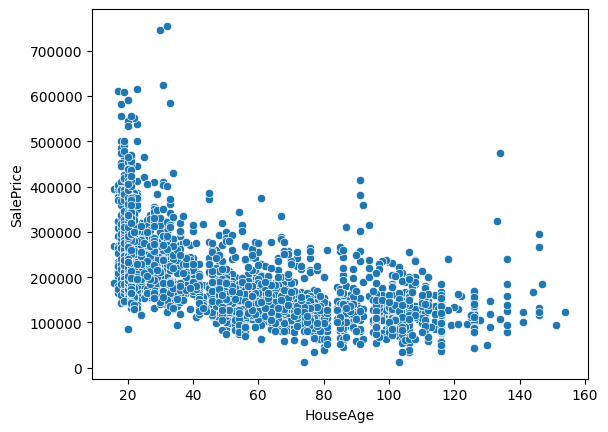

In [ ]:
sns.scatterplot(x=df['HouseAge'] , y=df['SalePrice'])

In [ ]:
Categorical_col

['MS Zoning',
 'Street',
 'Alley',
 'Lot Shape',
 'Land Contour',
 'Utilities',
 'Lot Config',
 'Land Slope',
 'Neighborhood',
 'Condition 1',
 'Condition 2',
 'Bldg Type',
 'House Style',
 'Roof Style',
 'Roof Matl',
 'Exterior 1st',
 'Exterior 2nd',
 'Mas Vnr Type',
 'Exter Qual',
 'Exter Cond',
 'Foundation',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin Type 2',
 'Heating',
 'Heating QC',
 'Central Air',
 'Electrical',
 'Kitchen Qual',
 'Functional',
 'Fireplace Qu',
 'Garage Type',
 'Garage Finish',
 'Garage Qual',
 'Garage Cond',
 'Paved Drive',
 'Pool QC',
 'Fence',
 'Misc Feature',
 'Sale Type',
 'Sale Condition']

In [ ]:
select_cat_col = ['Sale Condition' ,'House Style' , 'Neighborhood' , 'Roof Style']

select_num_col = ['Overall Qual','Gr Liv Area','Garage Cars', 'Total Bsmt SF','1st Flr SF', 'Full Bath', 'Bedroom AbvGr',"SalePrice"]

In [ ]:
Numerical_col

['Order',
 'PID',
 'MS SubClass',
 'Lot Frontage',
 'Lot Area',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 'Mas Vnr Area',
 'BsmtFin SF 1',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Gr Liv Area',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Full Bath',
 'Half Bath',
 'Bedroom AbvGr',
 'Kitchen AbvGr',
 'TotRms AbvGrd',
 'Fireplaces',
 'Garage Yr Blt',
 'Garage Cars',
 'Garage Area',
 'Wood Deck SF',
 'Open Porch SF',
 'Enclosed Porch',
 '3Ssn Porch',
 'Screen Porch',
 'Pool Area',
 'Misc Val',
 'Mo Sold',
 'Yr Sold',
 'SalePrice']

In [ ]:
final_df = df[select_cat_col + select_num_col ]

In [ ]:
final_df

,Sale Condition,House Style,Neighborhood,Roof Style,Overall Qual,Gr Liv Area,Garage Cars,Total Bsmt SF,1st Flr SF,Full Bath,Bedroom AbvGr,SalePrice
0,Normal,1Story,NAmes,Hip,6,1656,2.0,1080.0,1656,1,3,215000
1,Normal,1Story,NAmes,Gable,5,896,1.0,882.0,896,1,2,105000
2,Normal,1Story,NAmes,Hip,6,1329,1.0,1329.0,1329,1,3,172000
3,Normal,1Story,NAmes,Hip,7,2110,2.0,2110.0,2110,2,3,244000
4,Normal,2Story,Gilbert,Gable,5,1629,2.0,928.0,928,2,3,189900
...,...,...,...,...,...,...,...,...,...,...,...,...
2925,Normal,SLvl,Mitchel,Gable,6,1003,2.0,1003.0,1003,1,3,142500
2926,Normal,1Story,Mitchel,Gable,5,902,2.0,864.0,902,1,2,131000
2927,Normal,SFoyer,Mitchel,Gable,5,970,0.0,912.0,970,1,3,132000
2928,Normal,1Story,Mitchel,Gable,5,1389,2.0,1389.0,1389,1,2,170000


In [ ]:
final_df["Garage Cars"] = final_df['Garage Cars'].fillna(final_df['Garage Cars'].median())

In [ ]:
final_df.isna().sum()

,0
Sale Condition,0
House Style,0
Neighborhood,0
Roof Style,0
Overall Qual,0
Gr Liv Area,0
Garage Cars,0
Total Bsmt SF,1
1st Flr SF,0
Full Bath,0


In [ ]:
final_df["Total Bsmt SF"] = final_df["Total Bsmt SF"].fillna(final_df["Total Bsmt SF"].mean())

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale Condition  2930 non-null   object 
 1   House Style     2930 non-null   object 
 2   Neighborhood    2930 non-null   object 
 3   Roof Style      2930 non-null   object 
 4   Overall Qual    2930 non-null   int64  
 5   Gr Liv Area     2930 non-null   int64  
 6   Garage Cars     2930 non-null   float64
 7   Total Bsmt SF   2930 non-null   float64
 8   1st Flr SF      2930 non-null   int64  
 9   Full Bath       2930 non-null   int64  
 10  Bedroom AbvGr   2930 non-null   int64  
 11  SalePrice       2930 non-null   int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 274.8+ KB


In [ ]:
select_cat_col = ['Sale Condition' ,'House Style' , 'Neighborhood' , 'Roof Style']

In [ ]:
final_df_encoded = pd.get_dummies(final_df, columns=select_cat_col, drop_first=True)
display(final_df_encoded.head())

,Overall Qual,Gr Liv Area,Garage Cars,Total Bsmt SF,1st Flr SF,Full Bath,Bedroom AbvGr,SalePrice,Sale Condition_AdjLand,Sale Condition_Alloca,...,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Roof Style_Gable,Roof Style_Gambrel,Roof Style_Hip,Roof Style_Mansard,Roof Style_Shed
0,6,1656,2.0,1080.0,1656,1,3,215000,False,False,...,False,False,False,False,False,False,False,True,False,False
1,5,896,1.0,882.0,896,1,2,105000,False,False,...,False,False,False,False,False,True,False,False,False,False
2,6,1329,1.0,1329.0,1329,1,3,172000,False,False,...,False,False,False,False,False,False,False,True,False,False
3,7,2110,2.0,2110.0,2110,2,3,244000,False,False,...,False,False,False,False,False,False,False,True,False,False
4,5,1629,2.0,928.0,928,2,3,189900,False,False,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
final_df_encoded = final_df_encoded.astype(float)

In [ ]:
final_df_encoded

,Overall Qual,Gr Liv Area,Garage Cars,Total Bsmt SF,1st Flr SF,Full Bath,Bedroom AbvGr,SalePrice,Sale Condition_AdjLand,Sale Condition_Alloca,...,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Roof Style_Gable,Roof Style_Gambrel,Roof Style_Hip,Roof Style_Mansard,Roof Style_Shed
0,6.0,1656.0,2.0,1080.0,1656.0,1.0,3.0,215000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,5.0,896.0,1.0,882.0,896.0,1.0,2.0,105000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,6.0,1329.0,1.0,1329.0,1329.0,1.0,3.0,172000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,7.0,2110.0,2.0,2110.0,2110.0,2.0,3.0,244000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5.0,1629.0,2.0,928.0,928.0,2.0,3.0,189900.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,6.0,1003.0,2.0,1003.0,1003.0,1.0,3.0,142500.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2926,5.0,902.0,2.0,864.0,902.0,1.0,2.0,131000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2927,5.0,970.0,0.0,912.0,970.0,1.0,3.0,132000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2928,5.0,1389.0,2.0,1389.0,1389.0,1.0,2.0,170000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
X = final_df_encoded.drop('SalePrice' , axis=1)
y = final_df_encoded['SalePrice']

# Train test split


In [ ]:
from sklearn.model_selection import train_test_split

# train_test_split()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

## DATA SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
print(X_train_scaled[:2])

[[ 0.67394069 -0.24352173  0.33905809  0.09848243  0.55887697  0.80216958
   0.18881724 -0.05852057 -0.08796935  7.49471358 -2.19791851 -0.28579668
  -0.08290267  0.9839177  -0.05852057 -0.0950791  -0.64854149 -0.17284958
  -0.2154729  -0.05472927 -0.10170953 -0.19279041 -0.12311814 -0.31451821
  -0.19866517 -0.26147328 -0.2501133  -0.05472927 -0.02922278 -0.17928868
  -0.02065922 -0.10995367 -0.20777071 -0.43085357 -0.08025293  4.52819911
  -0.15787172 -0.23330441 -0.30458807 -0.1266418  -0.23126423 -0.20888544
  -0.24818179 -0.12489163 -0.1606878  -0.09733751  0.51077681 -0.09276773
  -0.47668137 -0.06208373 -0.0462349 ]
 [-0.76674967  1.25495594  0.33905809 -0.07796894  0.01346792  0.80216958
   0.18881724 -0.05852057 -0.08796935 -0.13342738 -2.19791851 -0.28579668
  -0.08290267 -1.01634517 -0.05852057 -0.0950791   1.5419214  -0.17284958
  -0.2154729  -0.05472927 -0.10170953 -0.19279041  8.12227976 -0.31451821
  -0.19866517 -0.26147328 -0.2501133  -0.05472927 -0.02922278 -0.17928868

## MODEL TRAINING


In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [ ]:
# model_lin.fit(X_train_scaled , y_train)
lr.fit(X_train_scaled , y_train)

LinearRegression()

In [ ]:
y_prediction_linear_test = lr.predict(X_test_scaled)
y_prediction_linear_train = lr.predict(X_train_scaled)

In [ ]:
def Accurecy(a , b):
  print(f"R2 Score : {r2_score(a , b)}")
  print(f"MSE : {mean_squared_error(a ,b  )}")
  print(f"MAE : {mean_absolute_error(a ,b)}")
  # adjusted = 1 - (1 - r2_score(a , b)) * ( a.shape[0]-1) / (a.shape[0] - a.shape[1] - 1)
  # print(f"Adjusted R2 Score : {adjusted}")


In [ ]:
print("Accurecy on testing data")
Accurecy(y_test , y_prediction_linear_test)

n = X_test.shape[0]
p = X_test.shape[1]
print(f"Adjusted R2 Score { 1 - ( 1 -  r2_score(y_test , y_prediction_linear_test) ) * (n-1) / ( n-p-1)}")

Accurecy on testing data
R2 Score : 0.8437572866818236
MSE : 1252683442.8835597
MAE : 21958.21732114803
Adjusted R2 Score 0.8288352297918854


In [ ]:
print("Accurecy on testing data")

Accurecy( y_train , y_prediction_linear_train)

Accurecy on testing data
R2 Score : 0.8294273194604879
MSE : 1014180669.751369
MAE : 20534.471966456793


##Ridge

In [ ]:
from sklearn.linear_model import Ridge

model = Ridge()

model.fit(X_train_scaled, y_train)

Ridge()

In [ ]:
y_prediction_ridge_test = model.predict(X_test_scaled)
y_prediction_ridge_train = model.predict(X_train_scaled)

In [ ]:
from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_error

In [ ]:
r2 = r2_score(y_test , y_prediction_ridge_test)
mse = mean_squared_error(y_test , y_prediction_ridge_test)
mae = mean_absolute_error(y_test , y_prediction_ridge_test)

In [ ]:
print('accurecy on testing data')
print(f"R2 Score : {r2}")
print(f"MSE : {mse}")
print(f"MAE : {mae}")

accurecy on testing data
R2 Score : 0.8438253403549425
MSE : 1252137819.2974544
MAE : 21952.596519042836


In [ ]:
print("Y-Testing Data Accurecy Ridge")
Accurecy(y_test , y_prediction_ridge_test)

n = y_test.shape[0]
p = X_test.shape[1]
print(f"adjusted r2 Score { 1 - (1-r2) * (n-1) / (n-p-1)}")

Y-Testing Data Accurecy Ridge
R2 Score : 0.8438253403549425
MSE : 1252137819.2974544
MAE : 21952.596519042836
adjusted r2 Score 0.8289097829731111


In [ ]:
print("Y-Training Data Accurecy Ridge")
Accurecy(y_train , y_prediction_ridge_train )

Y-Training Data Accurecy Ridge
R2 Score : 0.8294250669916812
MSE : 1014194062.343405
MAE : 20528.403703946376


## Creating Lasso model

In [ ]:
X_train_scaled

array([[ 0.67394069, -0.24352173,  0.33905809, ..., -0.47668137,
        -0.06208373, -0.0462349 ],
       [-0.76674967,  1.25495594,  0.33905809, ..., -0.47668137,
        -0.06208373, -0.0462349 ],
       [-1.48709485, -0.53291028,  0.33905809, ..., -0.47668137,
        -0.06208373, -0.0462349 ],
       ...,
       [-0.04640449,  0.46607484,  0.33905809, ..., -0.47668137,
        -0.06208373, -0.0462349 ],
       [-0.76674967,  0.4898602 , -1.00116478, ..., -0.47668137,
        -0.06208373, -0.0462349 ],
       [-0.76674967, -1.43675395, -1.00116478, ..., -0.47668137,
        -0.06208373, -0.0462349 ]])

In [ ]:
from sklearn.linear_model import Lasso
model_lasso = Lasso()

model_lasso.fit(X_train_scaled , y_train)

Lasso()

In [ ]:
y_test_pred_lasso = model_lasso.predict(X_test_scaled)
y_train_pred_lasso = model_lasso.predict(X_train_scaled)

print("Accurecy on testing data (Lasso)")
Accurecy(y_test, y_test_pred_lasso)
n = X_test.shape[0]
p = X_test.shape[1]
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)
print(f"Adjusted R2 Score (Test Lasso): { 1 - ( 1 - r2_test_lasso ) * (n-1) / ( n-p-1)}")

print("\nAccurecy on training data (Lasso)")
Accurecy(y_train, y_train_pred_lasso)
n_train = X_train.shape[0]
p_train = X_train.shape[1]
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)
print(f"Adjusted R2 Score (Train Lasso): { 1 - ( 1 - r2_train_lasso ) * (n_train-1) / ( n_train-p_train-1)}")

Accurecy on testing data (Lasso)
R2 Score : 0.843780033630953
MSE : 1252501068.1286325
MAE : 21956.30172379594
Adjusted R2 Score (Test Lasso): 0.8288601492024485

Accurecy on training data (Lasso)
R2 Score : 0.8294270387521987
MSE : 1014182338.7696422
MAE : 20532.919206584414
Adjusted R2 Score (Train Lasso): 0.8256315671013968


## FOR UI CREATION

In [ ]:
import joblib

#save model file
joblib.dump(model , "ridge_model.pkl")

# saving the standarScaler
joblib.dump(scaler  , 'scaler.pkl')

['scaler.pkl']